In [8]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import json

print("Analytics modeling libraries imported.")

Analytics modeling libraries imported.


In [9]:
import pandas as pd
print("Pandas OK")

import numpy as np
print("NumPy OK")

from sklearn.cluster import KMeans
print("Scikit-Learn OK")

import matplotlib.pyplot as plt
print("Matplotlib OK")

import json
print("JSON OK")

Pandas OK
NumPy OK
Scikit-Learn OK
Matplotlib OK
JSON OK


In [10]:
# Create artificial tracking parameters for 100 mock students
np.random.seed(42)
mock_data = {
    "student_id": range(1, 101),
    "weekly_hours_logged": np.random.uniform(2, 28, 100),
    "focus_rating_score": np.random.uniform(40, 100, 100) # Subjective completion index
}

df = pd.DataFrame(mock_data)
print(df.head())

   student_id  weekly_hours_logged  focus_rating_score
0           1            11.738043           41.885751
1           2            26.718572           78.184625
2           3            21.031842           58.861359
3           4            17.565121           70.514241
4           5             6.056485           94.453988


In [11]:
# Create artificial tracking parameters for 100 mock students
np.random.seed(42)
mock_data = {
    "student_id": range(1, 101),
    "weekly_hours_logged": np.random.uniform(2, 28, 100),
    "focus_rating_score": np.random.uniform(40, 100, 100) # Subjective completion index
}

df = pd.DataFrame(mock_data)
print(df.head())

   student_id  weekly_hours_logged  focus_rating_score
0           1            11.738043           41.885751
1           2            26.718572           78.184625
2           3            21.031842           58.861359
3           4            17.565121           70.514241
4           5             6.056485           94.453988


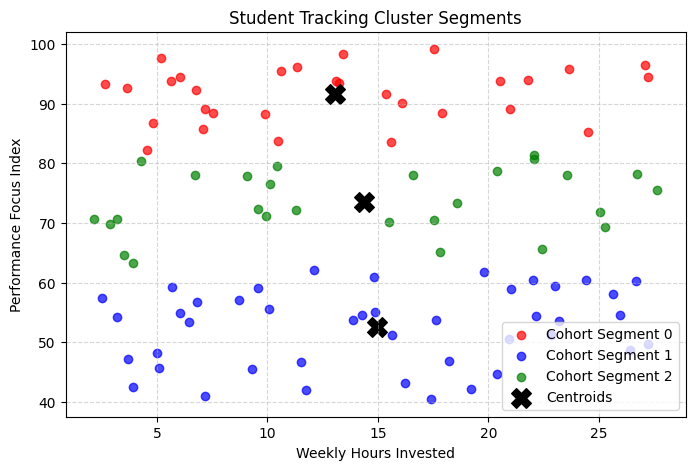

In [12]:
# Isolate feature sets for the algorithm
X = df[["weekly_hours_logged", "focus_rating_score"]]

# Segment cohorts into 3 actionable tracking buckets
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["behavioral_cluster"] = kmeans.fit_predict(X)

# Visualize cohorts
plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green']
for cluster in range(3):
    cluster_subset = df[df["behavioral_cluster"] == cluster]
    plt.scatter(cluster_subset["weekly_hours_logged"], cluster_subset["focus_rating_score"], 
                c=colors[cluster], label=f"Cohort Segment {cluster}", alpha=0.7)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', marker='X', label='Centroids')
plt.title("Student Tracking Cluster Segments")
plt.xlabel("Weekly Hours Invested")
plt.ylabel("Performance Focus Index")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()